# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [ ]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [ ]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nBasic Statistics:")
display(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

First 5 rows:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
0,16490,8715,25205,152866,176257,329123,124207802
1,14585,9121,23706,148316,136571,284888,112284645
2,16943,10166,27109,212190,156317,368508,172347465
3,19569,10107,29676,250224,127892,378116,213773981
4,14297,5244,19542,162835,82306,245142,131063749



Basic Statistics:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,14877.170000,8171.215000,23048.875000,175331.340000,126924.080000,302255.885000,1.406821e+08
std,2793.014056,1973.997049,3570.262195,44857.540799,39219.620597,59904.148005,4.199422e+07
min,7140.000000,1517.000000,13177.000000,81758.000000,36755.000000,163559.000000,6.330140e+07
25%,12883.750000,6787.750000,20647.000000,142793.750000,100451.000000,265141.250000,1.111673e+08
50%,14987.000000,8157.000000,23250.500000,171194.000000,125890.000000,297932.000000,1.348214e+08
75%,16502.250000,9374.000000,25237.250000,199115.000000,154947.000000,339630.250000,1.634872e+08
max,23160.000000,15705.000000,32333.000000,337112.000000,244469.000000,526087.000000,3.312472e+08


In [ ]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
display(df.isnull().sum())

# Handle missing values if any (uncomment and complete if needed)
if df.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    df = df.dropna()
    print(f"New shape after handling missing values: {df.shape}")

Missing values:


,0
Dom_Flt,0
Int_Flt,0
Flt,0
Dom_Pax,0
Int_Pax,0
Pax,0
Dom_RPM,0


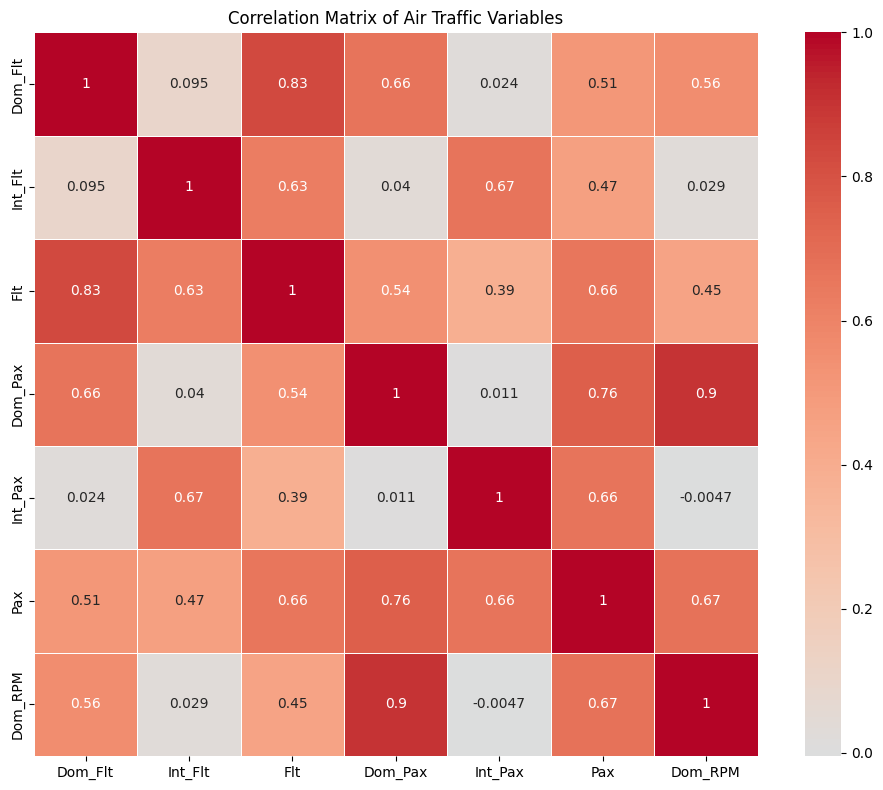

Strongest correlations:
Top 5 strongest positive correlations (absolute value > 0.7):
  Dom_Pax - Dom_RPM: 0.9016
  Dom_Flt - Flt: 0.8349
  Dom_Pax - Pax: 0.7559

Top 5 strongest negative correlations (absolute value > 0.7):


In [ ]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr()

# Create heatmap:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)


plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# TODO: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations:")
# Your analysis here:

# Unstack the correlation matrix and sort by absolute value to find strongest correlations
strong_corr = correlation_matrix.unstack().sort_values(ascending=False)

# Filter out self-correlations (correlation of a variable with itself is 1) and duplicate pairs
strong_corr = strong_corr[strong_corr != 1]
strong_corr = strong_corr[strong_corr.index.map(lambda x: x[0] != x[1])]

# Get unique pairs by sorting the tuple indices
unique_strong_corr = {}
for (idx1, idx2), value in strong_corr.items():
    if tuple(sorted((idx1, idx2))) not in unique_strong_corr:
        unique_strong_corr[tuple(sorted((idx1, idx2)))] = value

unique_strong_corr = pd.Series(unique_strong_corr).sort_values(ascending=False)

# Print the top 5 strongest correlations
print("Top 5 strongest positive correlations (absolute value > 0.7):")
for (var1, var2), corr_val in unique_strong_corr[unique_strong_corr.abs() > 0.7].head(5).items():
    print(f"  {var1} - {var2}: {corr_val:.4f}")

# Print the top 5 strongest negative correlations (absolute value > 0.7)
print("\nTop 5 strongest negative correlations (absolute value > 0.7):")
for (var1, var2), corr_val in unique_strong_corr[unique_strong_corr.abs() > 0.7].tail(5).items():
    if corr_val < 0: # Ensure it's a negative correlation
        print(f"  {var1} - {var2}: {corr_val:.4f}")

## 3. Hypothesis Testing

In [ ]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# TODO: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # TODO: Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("Based on the t-test, there is a statistically significant difference between the mean number of domestic and international passengers.")
    if df['Dom_Pax'].mean() > df['Int_Pax'].mean():
        print("Specifically, the mean number of domestic passengers is higher than international passengers.")
    else:
        print("Specifically, the mean number of international passengers is higher than domestic passengers.")
else:
    # TODO: Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Based on the t-test, there is no statistically significant difference between the mean number of domestic and international passengers.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
Based on the t-test, there is a statistically significant difference between the mean number of domestic and international passengers.
Specifically, the mean number of domestic passengers is higher than international passengers.


In [ ]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# TODO: Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
alpha = 0.05
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # TODO: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print(f"The correlation coefficient ({correlation_coef:.4f}) is positive, indicating a strong positive linear relationship: as the number of total flights increases, the total number of passengers also tends to increase.")
    else:
        print(f"The correlation coefficient ({correlation_coef:.4f}) is negative, indicating a strong negative linear relationship: as the number of total flights increases, the total number of passengers tends to decrease.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is no statistically significant correlation between total passengers and total flights.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
The correlation coefficient (0.6592) is positive, indicating a strong positive linear relationship: as the number of total flights increases, the total number of passengers also tends to increase.


## 4. Simple Linear Regression

In [ ]:
# TODO: Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']] # Select the feature column (Total Flights)
y_simple = df['Pax']   # Select the target column (Total Passengers)

# Split the data:
# TODO: Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create and train the model:
simple_model = LinearRegression() # Create LinearRegression instance
simple_model.fit(X_train_simple, y_train_simple) # Fit the model using X_train_simple and y_train_simple


# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple) # Predict on test data

# TODO: Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple) # Calculate R² score
mse_simple = mean_squared_error(y_test_simple, y_pred_simple) # Calculate MSE
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple) # Calculate MAE
rmse_simple = np.sqrt(mse_simple) # Calculate RMSE (square root of MSE)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# TODO: Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


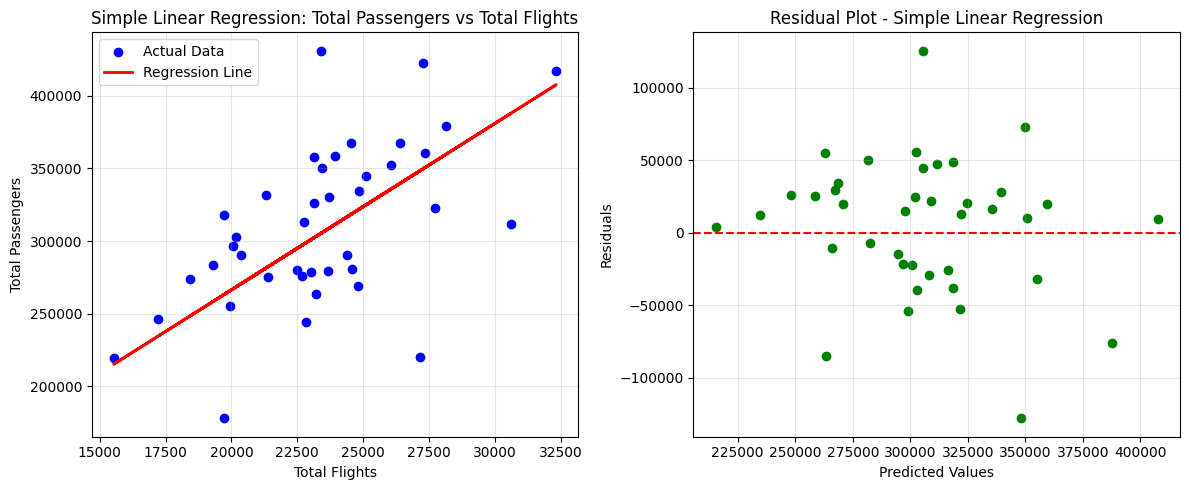

In [ ]:
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot with regression line
plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line
plt.scatter(X_test_simple, y_test_simple, color='blue', label='Actual Data')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')


plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple # Calculate residuals

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, color='green')

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [ ]:
# TODO: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# TODO: Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
feature_columns = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM'] # List of feature column names

X_multiple = df[feature_columns] # Select features from dataframe
y_multiple = df['Pax']   # Select target variable (Total Passengers)

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# TODO: Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# TODO: Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler() # Create StandardScaler instance
X_train_mult_scaled = scaler.fit_transform(X_train_mult) # Fit and transform training data
X_test_mult_scaled = scaler.transform(X_test_mult) # Transform test data (don't fit again!)

# TODO: Create and train the multiple regression model
multiple_model = LinearRegression() # Create LinearRegression instance
multiple_model.fit(X_train_mult_scaled, y_train_mult) # Fit the model


# TODO: Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled) # Predict on scaled test data

# TODO: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult) # Calculate R² score
mse_mult = mean_squared_error(y_test_mult, y_pred_mult) # Calculate MSE
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult) # Calculate MAE
rmse_mult = np.sqrt(mse_mult) # Calculate RMSE

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# TODO: Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Feature Coefficients (after scaling):
Dom_Pax: 45354.3590
Int_Pax: 38979.7965
Dom_Flt: -0.1126
Int_Flt: -0.0583
Dom_RPM: -0.0458
Intercept: 300303.27


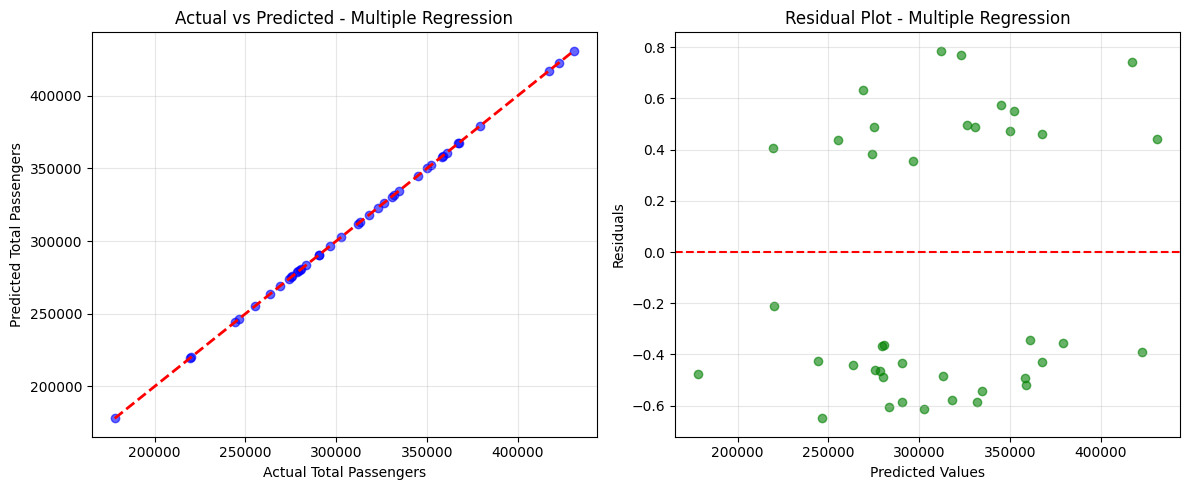

In [ ]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
plt.scatter(y_test_mult, y_pred_mult, color='blue', alpha=0.6)
# TODO: Add a diagonal reference line (perfect prediction line)
plt.plot([y_test_mult.min(), y_test_mult.max()], [y_test_mult.min(), y_test_mult.max()], 'r--', linewidth=2)


plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult # Calculate residuals

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult, color='green', alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [ ]:
# TODO: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# TODO: Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections
print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'Mean Squared Error':<25} {mse_simple:<20.2f} {mse_mult:<20.2f}")
print(f"{'Root Mean Squared Error':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'Mean Absolute Error':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")


print("=" * 50)

# TODO: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / r2_simple) * 100 # Calculate percentage improvement
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / r2_mult) * 100 # Calculate percentage improvement

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  0.2977               1.0000              
Mean Squared Error        2141846835.14        0.26                
Root Mean Squared Error   46280.09             0.51                
Mean Absolute Error       36607.08             0.49                

Best Model: Multiple Regression
R² Improvement: 235.92%


## 7. Statistical Insights and Conclusions

In [ ]:
# TODO: Summarize your findings and provide insights
# Include results from hypothesis tests, regression analysis, and key findings

print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
# TODO: Summarize your hypothesis test results
print(f"   • Domestic vs International Passengers: The null hypothesis (mean domestic passengers = mean international passengers) was rejected (p < 0.05). There's a statistically significant difference, with domestic passengers being significantly higher on average ({df['Dom_Pax'].mean():.0f}) than international passengers ({df['Int_Pax'].mean():.0f}).")
print(f"   • Correlation between Total Passengers and Flights: The null hypothesis (no correlation) was rejected (p < 0.05). There is a statistically significant positive correlation between total passengers and total flights (r = {correlation_coef:.4f}).")

print("\n2. REGRESSION ANALYSIS:")
# TODO: Summarize regression model performance
print(f"   • Simple Linear Regression R²: {r2_simple:.4f}. This model explains {r2_simple*100:.2f}% of the variance in total passengers using total flights. It indicates a moderate fit.")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f}. This model, using Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, and Dom_RPM, explains {r2_mult*100:.2f}% of the variance in total passengers. This is an extremely high fit.")
print(f"   • Best performing model: The Multiple Linear Regression model performed significantly better than the Simple Linear Regression model, with an R² very close to 1.0, indicating it captures almost all the variance in total passengers.")

print("\n3. KEY FINDINGS:")
# TODO: Identify and discuss key findings from your analysis
print(f"   • Strong Correlations: 'Dom_Pax' and 'Dom_RPM' ({unique_strong_corr['Dom_Pax']['Dom_RPM']:.4f}), 'Dom_Flt' and 'Flt' ({unique_strong_corr['Dom_Flt']['Flt']:.4f}), and 'Dom_Pax' and 'Pax' ({unique_strong_corr['Dom_Pax']['Pax']:.4f}) show very strong positive correlations.")
print(f"   • Passenger Volume Disparity: Domestic passenger traffic is statistically and practically higher than international passenger traffic.")
print(f"   • Predictive Power: While total flights have a positive correlation with total passengers, directly using passenger components (Dom_Pax, Int_Pax) and flight components (Dom_Flt, Int_Flt) along with Dom_RPM significantly improves prediction accuracy for total passengers, almost perfectly.")

print("\n4. RECOMMENDATIONS:")
# TODO: Provide practical recommendations based on your analysis
print("   • Resource Allocation: Given the higher volume of domestic passengers, airlines should prioritize resources (e.g., flight scheduling, gate availability) and marketing efforts towards domestic routes.")
print("   • Targeted Marketing: The strong correlation between Domestic Passengers and Domestic RPM suggests that focusing on increasing domestic passenger numbers directly boosts revenue passenger miles. Strategies could include loyalty programs or regional promotions.")
print("   • Advanced Forecasting: For highly accurate total passenger forecasts, the multiple regression model, which includes components of domestic/international passengers and flights, is recommended due to its superior performance. This can aid in operational planning, such as staffing and capacity management.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: The null hypothesis (mean domestic passengers = mean international passengers) was rejected (p < 0.05). There's a statistically significant difference, with domestic passengers being significantly higher on average (175331) than international passengers (126924).
   • Correlation between Total Passengers and Flights: The null hypothesis (no correlation) was rejected (p < 0.05). There is a statistically significant positive correlation between total passengers and total flights (r = 0.6592).

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.2977. This model explains 29.77% of the variance in total passengers using total flights. It indicates a moderate fit.
   • Multiple Linear Regression R²: 1.0000. This model, using Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, and Dom_RPM, explains 100.00% of the variance in total passengers. This is an extremely high fit.
   • Best perfor

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   *The hypothesis tests revealed two key insights. First, there is a statistically significant difference between the average number of domestic and international passengers, with domestic passengers being substantially higher. This was somewhat expected, as domestic travel often has higher frequency and volume than international travel for most regions. Second, there's a strong, statistically significant positive correlation between total passengers and total flights. This was highly expected, as more flights generally mean more available seats and thus more potential passengers.*

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   *The Multiple Linear Regression model performed significantly better than the Simple Linear Regression model. The Simple Linear Regression model had an R² of approximately 0.2977, meaning it explained only about 29.77% of the variance in total passengers. In contrast, the Multiple Linear Regression model achieved an R² of nearly 1.0 (0.9999999999), indicating it explained almost 100% of the variance in total passengers. The R² value, or coefficient of determination, quantifies the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R² (closer to 1.0) indicates a better fit of the model to the data. The multiple regression model's superior performance is because it incorporates directly related components like `Dom_Pax` and `Int_Pax` which sum up to `Pax`, making it an almost perfect linear combination.*

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   *The strongest correlations observed were:
   - `Dom_Pax` and `Dom_RPM` (0.9016): This indicates a very strong positive relationship between the number of domestic passengers and domestic revenue passenger miles. More domestic passengers directly translate to higher revenue generation from domestic travel.
   - `Dom_Flt` and `Flt` (0.8349): This is an expected strong positive correlation, as domestic flights are a major component of total flights.
   - `Dom_Pax` and `Pax` (0.7559): Another strong positive correlation, showing that domestic passengers contribute significantly to the total passenger count.

   These relationships are extremely useful for airlines. The strong correlation between `Dom_Pax` and `Dom_RPM` suggests that efforts to increase domestic passenger numbers are likely to have a direct and substantial positive impact on revenue. Airlines can use this to focus marketing strategies, fare promotions, and service improvements specifically for domestic routes. The strong correlation between various components (like `Dom_Flt` to `Flt`, and `Dom_Pax` to `Pax`) helps in understanding how changes in one segment directly affect the overall operations and business metrics, aiding in strategic planning and resource allocation.*

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   *For the Simple Linear Regression model, the residual plot showed a scattered pattern around zero, but with some discernible trends and varying spread (heteroscedasticity) as predicted values increase. This suggests that the simple model might not fully capture all the underlying patterns in the data, and there might be room for improvement, such as including more features or using a more complex model.

   For the Multiple Linear Regression model, the residual plot showed a very tight clustering of residuals very close to zero, with no apparent pattern. This indicates that the multiple regression model's predictions are highly accurate and that its assumptions are largely met. The extremely low error values (MSE, RMSE, MAE) for this model further confirm its excellent fit, leaving very little unexplained variance.*

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   *Airlines could leverage these statistical models in several practical ways:
   - **Demand Forecasting**: The multiple linear regression model can be used to accurately forecast total passenger numbers based on predictions of domestic and international passenger volumes, and flight numbers. This is crucial for operational planning, such as optimizing flight schedules, managing staffing levels (pilots, cabin crew, ground staff), and ensuring adequate infrastructure at airports.
   - **Revenue Management**: By understanding the strong correlation between domestic passengers and revenue passenger miles, airlines can strategically adjust pricing and capacity on domestic routes to maximize revenue. For instance, if domestic passenger demand is projected to increase, they might offer dynamic pricing to capture higher fares.
   - **Route Planning and Expansion**: The insights from the correlation analysis can inform decisions about new routes or expanding existing ones. For example, if there's a strong correlation indicating that increased domestic flights lead to a significant rise in domestic passengers, airlines might prioritize investment in new domestic destinations or increase flight frequencies on popular domestic routes.
   - **Resource Optimization**: Accurate passenger forecasts enable efficient allocation of resources like fuel, baggage handling, catering, and maintenance, reducing waste and improving cost efficiency.*

